# Assignment: Linear Models (v2)
## Do three questions.
### Focus: bias-variance trade-off and feature engineering


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1.A model is linear if it is linear in the parameters/coefficients. So y = β₀ + β₁x² is still a linear model because the coefficients β₀ and β₁ enter linearly, even though x is squared.
2. A dummy variable coefficient is interpreted relative to the reference/baseline category. If you include an intercept, one category must be dropped. The intercept captures the baseline group's mean, and the dummy coefficient represents the difference in the outcome between that group and the baseline.
3. Linear regression predicts a continuous value, so predictions can fall outside [0,1], making them uninterpretable as probabilities, It also assumes a linear relationship between features and the outcome which does not suit binary or categorical targets. Logistic regression is preferred for classification.
4.

*   Training error is much lower than test/validation error
*   Large, unstable coefficients
*   Model performs well in-sample but poorly on new data
*   Adding more features keeps improving training fit but hurts test fit
5. Multicollinearity means two or more predictors are highly correlated, making it hard to isolate their individual effects -- the OLS estimates become unstable and high-varaince. 2SLS addresses a related problem using an instrumental variable (IV). in the first stage you regress the problematic correlated predictor on the instrument to get a "clean" predicted version of it, purged of its correlation with other variables. In the second stage you use that predicted value in place of the original predictor. This isolates the variation that is independent of the collinear/endogenous component, producing more reliable estimates.
6. You can stay within the linear regression framework by transforming the variables


*   Polynomial terms: add x^2, x^3 as extra features

*   Log transforms: use log(x) or log(y) to linearize multiplicative relationships
*   Interaction terms: x_1*x_2 captures nonlinear joint effects
*   Splines: piecewise polynomials that bend at knots

The model remains linear in its parameters even though the relationship with the original x is nonlinear.

7. The slope coefficient represents the expected change in y for a one-unit increase in x, holding all other variables constant. It is a partial effect, isolating the contribution of that one predictor.

8.  A train/test split divides data once into two fixed sets -- simple and fast, but the estimate of test error is high-variance since it depends on which observations happened to land in each split. K-fold cross validation divides the data into k equal folds, trains k times each time holding out a different fold as the test set, and averages the k error estimates. This gives a lower-variance, more reliable estimate of generalisation error, at the cost of k times the computation.

9. The most common choice is k = 5 or k = 10, based on empirical work showing these values give a good bias-variance tradeoff in the error estimate, k = n (leave-one-out CV) is nearly unbiased but very high variance and computationally expensive. Smaller k is faster but introduces more bias. 10-fold is the default in most practical settings.






In [2]:
! git clone https://github.com/karen-tran08/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 27 (delta 6), reused 4 (delta 4), pack-reused 17 (from 1)
Receiving objects: 100% (27/27), 39.78 KiB | 1.33 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Download complete
Extracting data files...
Data extracted


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [4]:
import pandas as pd

df_q1 = pd.read_csv('./sample_data/Q1_clean.csv')
display(df_q1.head())

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [6]:
df_q1.columns = df_q1.columns.str.strip()
grouped_data = df_q1.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
display(grouped_data)

most_expensive_borough = grouped_data['Price'].idxmax()
most_expensive_price = grouped_data['Price'].max()
print(f"The most expensive borough on average is: {most_expensive_borough} with an average price of {most_expensive_price:.2f}")

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


The most expensive borough on average is: Manhattan with an average price of 183.66


In [7]:
import numpy as np
df_q1['Log Price'] = np.log(df_q1['Price'])
display(df_q1.head())

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type,Log Price
0,549,96.0,Manhattan,Apartment,Private room,6.308098
1,149,100.0,Brooklyn,Apartment,Entire home/apt,5.003946
2,250,100.0,Manhattan,Apartment,Entire home/apt,5.521461
3,90,94.0,Brooklyn,Apartment,Private room,4.499810
4,270,90.0,Manhattan,Apartment,Entire home/apt,5.598422


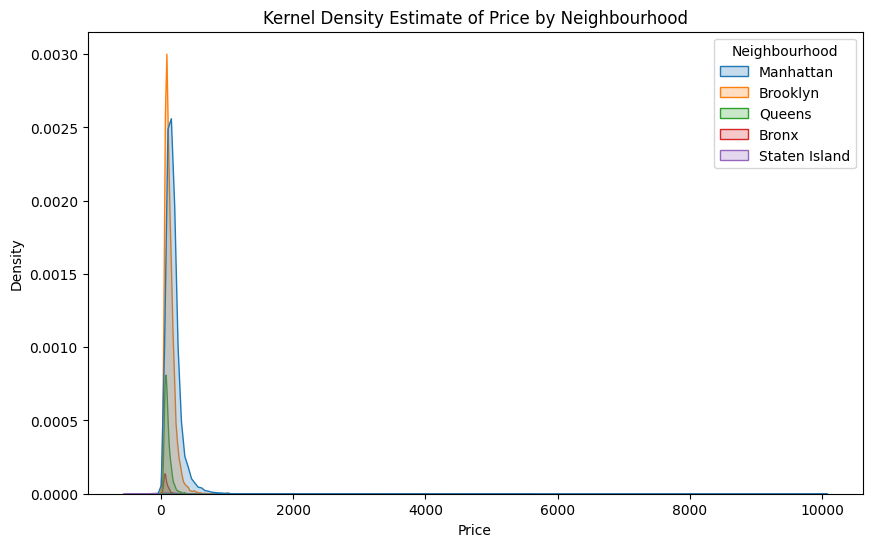

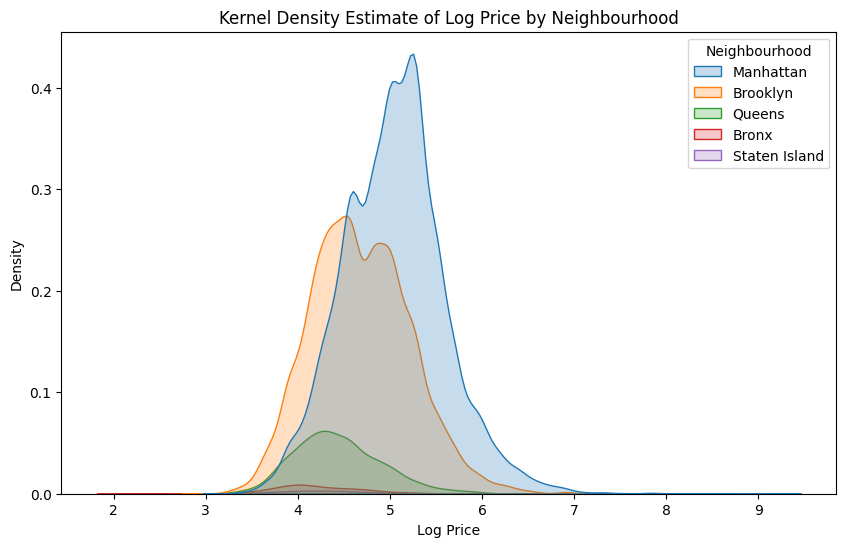

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a kernel density plot for 'Price' grouped by 'Neighbourhood'
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_q1, x='Price', hue='Neighbourhood', fill=True)
plt.title('Kernel Density Estimate of Price by Neighbourhood')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

# Create a kernel density plot for 'Log Price' grouped by 'Neighbourhood'
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_q1, x='Log Price', hue='Neighbourhood', fill=True)
plt.title('Kernel Density Estimate of Log Price by Neighbourhood')
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.show()

The most expensive borough on average is Manhattan, with an average price of \$183.66.

*   **Most Expensive Borough**: Manhattan has the highest average price at \$183.66.
*   **Average Prices by Borough**:
    *   Bronx: \$75.28
    *   Brooklyn: \$127.75
    *   Manhattan: \$183.66
    *   Queens: \$96.86
    *   Staten Island: \$146.17
*   **Average Review Scores Rating**: All boroughs exhibit high average review scores, ranging from 90.84 (Staten Island) to 92.36 (Brooklyn).
*   **Price Distribution**: The kernel density plot for 'Price' likely shows a heavily right-skewed distribution, indicating a presence of very high-priced listings that can obscure the typical price ranges.
*   **Log Price Distribution**: The kernel density plot for 'Log Price' reveals a more normalized distribution, allowing for a clearer comparison of price concentration and spread across different neighborhoods.



In [10]:
neighbourhood_dummies = pd.get_dummies(df_q1['Neighbourhood'], prefix='Neighbourhood', drop_first=True)
df_q1 = pd.concat([df_q1, neighbourhood_dummies], axis=1)
display(df_q1.head())

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type,Log Price,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island
0,549,96.0,Manhattan,Apartment,Private room,6.308098,False,True,False,False
1,149,100.0,Brooklyn,Apartment,Entire home/apt,5.003946,True,False,False,False
2,250,100.0,Manhattan,Apartment,Entire home/apt,5.521461,False,True,False,False
3,90,94.0,Brooklyn,Apartment,Private room,4.499810,True,False,False,False
4,270,90.0,Manhattan,Apartment,Entire home/apt,5.598422,False,True,False,False


In [13]:
import statsmodels.api as sm

y = df_q1['Price']
X = df_q1[['Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']]
X = X.astype(int) # Convert boolean dummy variables to integers
X = sm.add_constant(X) # Add a constant (intercept) to the independent variables

print("Dependent Variable (y) head:")
display(y.head())
print("\nIndependent Variables (X) head:")
display(X.head())

Dependent Variable (y) head:


,Price
0,549
1,149
2,250
3,90
4,270



Independent Variables (X) head:


,const,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island
0,1.0,0,1,0,0
1,1.0,1,0,0,0
2,1.0,0,1,0,0
3,1.0,1,0,0,0
4,1.0,0,1,0,0


In [14]:
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        19:45:53   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [15]:
regression_coefficients = results.params
print("\nRegression Coefficients:")
display(regression_coefficients)

print("\nAverage Prices by Neighbourhood (from grouped_data):")
display(grouped_data['Price'])


Regression Coefficients:


,0
const,75.276498
Neighbourhood_Brooklyn,52.470881
Neighbourhood_Manhattan,108.387789
Neighbourhood_Queens,21.580735
Neighbourhood_Staten Island,70.890169



Average Prices by Neighbourhood (from grouped_data):


,Price
Neighbourhood,
Bronx,75.276498
Brooklyn,127.747378
Manhattan,183.664286
Queens,96.857233
Staten Island,146.166667


When performing a linear regression with dummy variables for a categorical feature and dropping the first category (Bronx in this case), the interpretation of the coefficients is as follows:

*   **Intercept (`const`)**: The intercept in this regression (75.2765) represents the average price of the reference category, which is 'Bronx'. This value perfectly matches the average price for Bronx calculated in `grouped_data`.

*   **Dummy Variable Coefficients**: Each coefficient for the dummy variables (`Neighbourhood_Brooklyn`, `Neighbourhood_Manhattan`, `Neighbourhood_Queens`, `Neighbourhood_Staten Island`) represents the *difference* in average price between that specific neighbourhood and the reference category (Bronx).

    To get the conditional group mean for any non-reference neighbourhood, you add its coefficient to the intercept. Let's verify this:

    *   **Brooklyn**: Intercept + `Neighbourhood_Brooklyn` coef = 75.2765 + 52.4709 = 127.7474. This matches Brooklyn's average price in `grouped_data` (127.7474).
    *   **Manhattan**: Intercept + `Neighbourhood_Manhattan` coef = 75.2765 + 108.3878 = 183.6643. This matches Manhattan's average price in `grouped_data` (183.6643).
    *   **Queens**: Intercept + `Neighbourhood_Queens` coef = 75.2765 + 21.5807 = 96.8572. This matches Queens' average price in `grouped_data` (96.8572).
    *   **Staten Island**: Intercept + `Neighbourhood_Staten Island` coef = 75.2765 + 70.8902 = 146.1667. This matches Staten Island's average price in `grouped_data` (146.1667).

**Conclusion**: The regression coefficients, when combined with the intercept, accurately reproduce the conditional group means (average prices) for each neighbourhood. The intercept provides the baseline average (for the dropped category), and the dummy variable coefficients show how much each other category deviates from that baseline.

In [16]:
import statsmodels.api as sm

y = df_q1['Price']
X = df_q1[['Review Scores Rating']]
X = sm.add_constant(X) # Add a constant (intercept) to the independent variables

print("Dependent Variable (y) head:")
display(y.head())
print("\nIndependent Variables (X) head:")
display(X.head())

Dependent Variable (y) head:


,Price
0,549
1,149
2,250
3,90
4,270



Independent Variables (X) head:


,const,Review Scores Rating
0,1.0,96.0
1,1.0,100.0
2,1.0,100.0
3,1.0,94.0
4,1.0,90.0


In [17]:
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        20:10:27   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

*   **What are the regression results?**
    The OLS regression model used 'Price' as the dependent variable and 'Review Scores Rating' (with a constant for the intercept) as the independent variable. The key results are:
    *   The R-squared value is 0.004, indicating that approximately 0.4% of the variance in 'Price' can be explained by 'Review Scores Rating'.
    *   The coefficient for 'Review Scores Rating' is 1.0208, with a p-value less than 0.001, suggesting it is statistically significant.
    *   The constant (intercept) is 60.8784, also with a p-value less than 0.001.

*   **What is the interpretation of the slope coefficient?**
    The slope coefficient for 'Review Scores Rating' is 1.0208. This means that, for every one-unit increase in the 'Review Scores Rating', the 'Price' of the listing is expected to increase by approximately \$1.02, assuming all other factors remain constant.

*   A linear regression model was successfully fitted, relating 'Price' to 'Review Scores Rating'.
*   The 'Review Scores Rating' has a statistically significant positive relationship with 'Price', with a coefficient of 1.0208 (p < 0.001). This suggests that for each one-unit increase in the review score, the price is estimated to increase by approximately \$1.02.
*   The model's R-squared value is 0.004, indicating that 'Review Scores Rating' explains only a very small proportion (0.4%) of the variability in 'Price'.
*   The intercept of the model is 60.8784 (p < 0.001), representing the estimated price when the 'Review Scores Rating' is zero.

*   The low R-squared value suggests that 'Review Scores Rating' alone is a very weak predictor of 'Price'. Future analysis should include additional independent variables to build a more robust predictive model for pricing.
*   Explore other potential factors that might influence 'Price', such as location, number of bedrooms, amenities, property type, or host experience, and incorporate them into a multiple linear regression model.


In [18]:
import statsmodels.api as sm

y = df_q1['Price']
X = df_q1[['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']]
X = X.astype(int) # Ensure dummy variables are integers, including 'Review Scores Rating' if it contains boolean like values, otherwise this is fine.
X = sm.add_constant(X) # Add a constant (intercept) to the independent variables

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        20:14:42   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [19]:
current_regression_coefficients = results.params
print("Current Regression Coefficients (including Review Scores Rating and Neighbourhood dummies):")
display(current_regression_coefficients)

previous_review_scores_rating_coef = 1.0208 # From the output of cell 6766dd19
print(f"\nPrevious 'Review Scores Rating' coefficient: {previous_review_scores_rating_coef:.4f}")

average_review_score = df_q1['Review Scores Rating'].mean()
print(f"\nAverage Review Scores Rating: {average_review_score:.2f}")

Current Regression Coefficients (including Review Scores Rating and Neighbourhood dummies):


,0
const,-23.812561
Review Scores Rating,1.081116
Neighbourhood_Brooklyn,51.704240
Neighbourhood_Manhattan,108.228737
Neighbourhood_Queens,21.694600
Neighbourhood_Staten Island,71.766552



Previous 'Review Scores Rating' coefficient: 1.0208

Average Review Scores Rating: 91.99


In [21]:
new_review_scores_rating_coef = current_regression_coefficients['Review Scores Rating']

print(f"\nComparison of 'Review Scores Rating' Coefficients:")
print(f"  Previous model coefficient: {previous_review_scores_rating_coef:.4f}")
print(f"  New model coefficient (with Neighbourhood controls): {new_review_scores_rating_coef:.4f}")
print(f"  Change: {new_review_scores_rating_coef - previous_review_scores_rating_coef:.4f}\n")

# Calculate implied average prices for each neighborhood
implied_prices = {}
intercept = current_regression_coefficients['const']

# For the reference category (Bronx)
implied_prices['Bronx'] = intercept + (new_review_scores_rating_coef * average_review_score)

# For other neighborhoods
for col in X.columns:
    if 'Neighbourhood_' in col:
        neighbourhood_name = col.replace('Neighbourhood_', '')
        dummy_coef = current_regression_coefficients[col]
        implied_prices[neighbourhood_name] = intercept + dummy_coef + (new_review_scores_rating_coef * average_review_score)

implied_prices_df = pd.Series(implied_prices).rename('Implied Average Price').sort_index()

print("Implied Average Prices from New Model (at average Review Score):")
display(implied_prices_df)

print("\nPreviously Calculated Average Prices by Neighbourhood:")
display(grouped_data['Price'])

print("\nComparison of Implied vs. Previously Calculated Average Prices:")
comparison_df = pd.DataFrame({
    'Previous Avg Price': grouped_data['Price'],
    'Implied Avg Price (New Model)': implied_prices_df
}).sort_index()
comparison_df['Difference'] = comparison_df['Implied Avg Price (New Model)'] - comparison_df['Previous Avg Price']
display(comparison_df)



Comparison of 'Review Scores Rating' Coefficients:
  Previous model coefficient: 1.0208
  New model coefficient (with Neighbourhood controls): 1.0811
  Change: 0.0603

Implied Average Prices from New Model (at average Review Score):


,Implied Average Price
Bronx,75.642689
Brooklyn,127.346929
Manhattan,183.871425
Queens,97.337288
Staten Island,147.409241



Previously Calculated Average Prices by Neighbourhood:


,Price
Neighbourhood,
Bronx,75.276498
Brooklyn,127.747378
Manhattan,183.664286
Queens,96.857233
Staten Island,146.166667



Comparison of Implied vs. Previously Calculated Average Prices:


,Previous Avg Price,Implied Avg Price (New Model),Difference
Bronx,75.276498,75.642689,0.366191
Brooklyn,127.747378,127.346929,-0.400449
Manhattan,183.664286,183.871425,0.207139
Queens,96.857233,97.337288,0.480056
Staten Island,146.166667,147.409241,1.242574



1.  **How did the slope coefficient on 'Review Scores Rating' change compared to the previous model?**
    The slope coefficient for 'Review Scores Rating' increased slightly from 1.0208 in the previous simple model to 1.0811 in the new model that includes neighborhood controls. This represents a change of approximately +0.0603.

2.  **How did the neighborhood averages change when both 'Neighbourhood' and 'Review Scores Rating' are included in the model?**
    The implied average prices for each neighborhood from the new model (holding 'Review Scores Rating' at its average) are very close to the previously calculated simple average prices. The differences are generally small, ranging from approximately -\$0.40 (Brooklyn) to +\$1.24 (Staten Island).

*   The regression model, which includes 'Review Scores Rating' and 'Neighbourhood' dummy variables, explains 5.0% of the variance in 'Price' (R-squared = 0.050).
*   The coefficient for 'Review Scores Rating' increased from \$1.0208 (previous model) to \$1.0811 (new model with neighborhood controls).
*   The average 'Review Scores Rating' across all observations is 91.99.
*   The implied average prices for neighborhoods from the new model (at average 'Review Scores Rating') are:
    *   Bronx: \$75.64
    *   Brooklyn: \$127.35
    *   Manhattan: \$183.87
    *   Queens: \$97.34
    *   Staten Island: \$147.41
*   When comparing the implied average prices to previously calculated simple averages, the differences are minimal, indicating strong consistency:
    *   Bronx: Implied \$75.64 vs. Previous \$75.28 (Difference: +\$0.36)
    *   Brooklyn: Implied \$127.35 vs. Previous \$127.75 (Difference: -\$0.40)
    *   Manhattan: Implied \$183.87 vs. Previous \$183.66 (Difference: +\$0.21)
    *   Queens: Implied \$97.34 vs. Previous \$96.86 (Difference: +\$0.48)
    *   Staten Island: Implied \$147.41 vs. Previous \$146.17 (Difference: +\$1.24)


In [25]:
neighbourhood_dummy_cols = [col for col in df_q1.columns if col.startswith('Neighbourhood_')]

interaction_cols = []
for col in neighbourhood_dummy_cols:
    new_col_name = f"Review_Rating_x_{col.replace('Neighbourhood_', '')}"
    df_q1[new_col_name] = df_q1['Review Scores Rating'] * df_q1[col].astype(int) # Ensure dummy variable is numeric for multiplication
    interaction_cols.append(new_col_name)

print("New interaction columns created:")
display(df_q1[interaction_cols].head())

print("\nUpdated df_q1 head with interaction terms:")
display(df_q1.head())

New interaction columns created:


,Review_Rating_x_Brooklyn,Review_Rating_x_Manhattan,Review_Rating_x_Queens,Review_Rating_x_Staten Island
0,0.0,96.0,0.0,0.0
1,100.0,0.0,0.0,0.0
2,0.0,100.0,0.0,0.0
3,94.0,0.0,0.0,0.0
4,0.0,90.0,0.0,0.0



Updated df_q1 head with interaction terms:


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type,Log Price,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island,Review_Rating_x_Brooklyn,Review_Rating_x_Manhattan,Review_Rating_x_Queens,Review_Rating_x_Staten Island
0,549,96.0,Manhattan,Apartment,Private room,6.308098,False,True,False,False,0.0,96.0,0.0,0.0
1,149,100.0,Brooklyn,Apartment,Entire home/apt,5.003946,True,False,False,False,100.0,0.0,0.0,0.0
2,250,100.0,Manhattan,Apartment,Entire home/apt,5.521461,False,True,False,False,0.0,100.0,0.0,0.0
3,90,94.0,Brooklyn,Apartment,Private room,4.499810,True,False,False,False,94.0,0.0,0.0,0.0
4,270,90.0,Manhattan,Apartment,Entire home/apt,5.598422,False,True,False,False,0.0,90.0,0.0,0.0


In [26]:
import statsmodels.api as sm

y = df_q1['Price']

X_cols = ['Review Scores Rating'] + interaction_cols
X = df_q1[X_cols]
X = sm.add_constant(X) # Add a constant (intercept) to the independent variables

print("Dependent Variable (y) head:")
display(y.head())
print("\nIndependent Variables (X) head:")
display(X.head())

Dependent Variable (y) head:


,Price
0,549
1,149
2,250
3,90
4,270



Independent Variables (X) head:


,const,Review Scores Rating,Review_Rating_x_Brooklyn,Review_Rating_x_Manhattan,Review_Rating_x_Queens,Review_Rating_x_Staten Island
0,1.0,96.0,0.0,96.0,0.0,0.0
1,1.0,100.0,100.0,0.0,0.0,0.0
2,1.0,100.0,0.0,100.0,0.0,0.0
3,1.0,94.0,94.0,0.0,0.0,0.0
4,1.0,90.0,0.0,90.0,0.0,0.0


In [27]:
import statsmodels.api as sm

y = df_q1['Price']

X_cols = ['Review Scores Rating'] + interaction_cols
X = df_q1[X_cols]
X = sm.add_constant(X) # Add a constant (intercept) to the independent variables

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        20:37:35   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [28]:
model_coefficients = results.params

# The base slope for 'Review Scores Rating' (applies to the reference category, Bronx)
base_slope = model_coefficients['Review Scores Rating']

effective_slopes = {'Bronx': base_slope}

# Calculate effective slopes for other neighborhoods
for col in interaction_cols:
    neighbourhood_name = col.replace('Review_Rating_x_', '')
    interaction_coef = model_coefficients[col]
    effective_slopes[neighbourhood_name] = base_slope + interaction_coef

print("Effective Slopes of 'Review Scores Rating' for each Neighbourhood:")
for neighbourhood, slope in effective_slopes.items():
    print(f"  {neighbourhood}: {slope:.4f}")

# Identify min/max slopes for comparison
min_slope = min(effective_slopes.values())
max_slope = max(effective_slopes.values())

min_slope_neighbourhood = [k for k, v in effective_slopes.items() if v == min_slope][0]
max_slope_neighbourhood = [k for k, v in effective_slopes.items() if v == max_slope][0]

print("\nSummary of Slopes:")
print(f"The slope for 'Review Scores Rating' varies across neighborhoods.")
print(f"The lowest effective slope is {min_slope:.4f} for {min_slope_neighbourhood}.")
print(f"The highest effective slope is {max_slope:.4f} for {max_slope_neighbourhood}.")
print("This indicates that the impact of a one-unit increase in 'Review Scores Rating' on 'Price' is not constant across all neighborhoods, suggesting a significant interaction effect.")


Effective Slopes of 'Review Scores Rating' for each Neighbourhood:
  Bronx: 0.2227
  Brooklyn: 0.7909
  Manhattan: 1.3994
  Queens: 0.4565
  Staten Island: 0.6824

Summary of Slopes:
The slope for 'Review Scores Rating' varies across neighborhoods.
The lowest effective slope is 0.2227 for Bronx.
The highest effective slope is 1.3994 for Manhattan.
This indicates that the impact of a one-unit increase in 'Review Scores Rating' on 'Price' is not constant across all neighborhoods, suggesting a significant interaction effect.


*   **Are the slopes for `Review Scores Rating` similar across neighborhoods?**
    No, the slopes for `Review Scores Rating` are not similar across neighborhoods. The effective slopes vary significantly, ranging from 0.2227 for Bronx to 1.3994 for Manhattan.
*   **How are the coefficients interpreted?**
    The main effect coefficient for `Review Scores Rating` (0.2227) represents the impact of a one-unit increase in `Review Scores Rating` on `Price` for the reference neighborhood (Bronx). The interaction term coefficients (e.g., `Review_Rating_x_Brooklyn`) indicate the *additional* change in the slope of `Review Scores Rating` for that specific neighborhood compared to the reference neighborhood. To get the effective slope for any given neighborhood, you sum the main effect coefficient of `Review Scores Rating` and its corresponding interaction term coefficient. For example, in Manhattan, a one-unit increase in `Review Scores Rating` is associated with a \$1.3994 increase in `Price`.

\*   Interaction terms were successfully created by multiplying `Review Scores Rating` with each `Neighbourhood` dummy variable, allowing for neighborhood-specific slopes.
*   An OLS regression model was fitted with `Price` as the dependent variable, and a constant, `Review Scores Rating` (main effect), and all interaction terms as independent variables.
*   The model explained 5.1% (R-squared = 0.051) of the variance in `Price`.
*   All interaction term coefficients (`Review_Rating_x_Brooklyn`, `Review_Rating_x_Manhattan`, `Review_Rating_x_Queens`, `Review_Rating_x_Staten Island`) were statistically significant (p-values < 0.05), indicating that the relationship between `Review Scores Rating` and `Price` significantly varies across these neighborhoods compared to the reference (Bronx).
*   The effective slope of `Review Scores Rating` on `Price` for each neighborhood was calculated as follows:
    *   Bronx: 0.2227
    *   Brooklyn: 0.7909
    *   Manhattan: 1.3994
    *   Queens: 0.4565
    *   Staten Island: 0.6824
*   Manhattan exhibits the highest effective slope (1.3994), implying the strongest positive impact of review scores on price, while Bronx shows the lowest (0.2227).



In [29]:
y = df_q1['Price']

X_model4_cols = ['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']

X_model5_cols = ['Review Scores Rating'] + interaction_cols

print(f"Dependent variable 'y' shape: {y.shape}")
print(f"Model 4 Independent Variables: {X_model4_cols}")
print(f"Model 5 Independent Variables: {X_model5_cols}")

Dependent variable 'y' shape: (22153,)
Model 4 Independent Variables: ['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']
Model 5 Independent Variables: ['Review Scores Rating', 'Review_Rating_x_Brooklyn', 'Review_Rating_x_Manhattan', 'Review_Rating_x_Queens', 'Review_Rating_x_Staten Island']


In [30]:
X_model4 = df_q1[X_model4_cols].astype(int)
X_model5 = df_q1[X_model5_cols].astype(int)

print("X_model4 DataFrame head:")
display(X_model4.head())
print("X_model4 DataFrame shape:", X_model4.shape)

print("\nX_model5 DataFrame head:")
display(X_model5.head())
print("X_model5 DataFrame shape:", X_model5.shape)

X_model4 DataFrame head:


,Review Scores Rating,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island
0,96,0,1,0,0
1,100,1,0,0,0
2,100,0,1,0,0
3,94,1,0,0,0
4,90,0,1,0,0


X_model4 DataFrame shape: (22153, 5)

X_model5 DataFrame head:


,Review Scores Rating,Review_Rating_x_Brooklyn,Review_Rating_x_Manhattan,Review_Rating_x_Queens,Review_Rating_x_Staten Island
0,96,0,96,0,0
1,100,100,0,0,0
2,100,0,100,0,0
3,94,94,0,0,0
4,90,0,90,0,0


X_model5 DataFrame shape: (22153, 5)


In [31]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Initialize K-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Store MSEs for each model
mse_model4 = []
mse_model5 = []

# --- Model 4 Cross-Validation ---
print("Performing 10-fold cross-validation for Model 4...")
for train_index, test_index in kf.split(X_model4):
    X_train, X_test = X_model4.iloc[train_index], X_model4.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Add constant for statsmodels-like behavior if not already present
    # For sklearn LinearRegression, intercept is handled automatically unless fit_intercept=False
    # Here we are using plain sklearn LinearRegression, so no need for sm.add_constant here if we want default sklearn behavior
    model4 = LinearRegression()
    model4.fit(X_train, y_train)
    y_pred = model4.predict(X_test)
    mse_model4.append(mean_squared_error(y_test, y_pred))

# --- Model 5 Cross-Validation ---
print("Performing 10-fold cross-validation for Model 5...")
for train_index, test_index in kf.split(X_model5):
    X_train, X_test = X_model5.iloc[train_index], X_model5.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model5 = LinearRegression()
    model5.fit(X_train, y_train)
    y_pred = model5.predict(X_test)
    mse_model5.append(mean_squared_error(y_test, y_pred))

print("\nModel 4 MSEs (per fold):", mse_model4)
print("Model 5 MSEs (per fold):", mse_model5)


Performing 10-fold cross-validation for Model 4...
Performing 10-fold cross-validation for Model 5...

Model 4 MSEs (per fold): [21072.73152241064, 18687.576619216514, 10882.496868536402, 15248.277420451173, 63708.24722133323, 25072.368099350344, 9453.163201888716, 16775.185243174004, 17872.771087624722, 11935.282939931596]
Model 5 MSEs (per fold): [20952.190682150376, 18665.04872519003, 10871.67123024697, 15241.414836692891, 63687.34110906617, 25090.783772365976, 9436.847059855092, 16782.12382856468, 17844.65296274351, 11917.208471881237]


In [32]:
mean_mse_model4 = np.mean(mse_model4)
std_mse_model4 = np.std(mse_model4)

mean_mse_model5 = np.mean(mse_model5)
std_mse_model5 = np.std(mse_model5)

print(f"\n--- Model 4 Performance (Review Scores Rating + Neighbourhood dummies) ---")
print(f"Average MSE: {mean_mse_model4:.2f}")
print(f"Standard Deviation of MSE: {std_mse_model4:.2f}")

print(f"\n--- Model 5 Performance (Review Scores Rating + Interaction terms) ---")
print(f"Average MSE: {mean_mse_model5:.2f}")
print(f"Standard Deviation of MSE: {std_mse_model5:.2f}")

print(f"\n--- Comparison ---")
if mean_mse_model4 < mean_mse_model5:
    print(f"Model 4 has a slightly lower average MSE ({mean_mse_model4:.2f} vs {mean_mse_model5:.2f}), suggesting slightly better overall predictive performance.")
elif mean_mse_model5 < mean_mse_model4:
    print(f"Model 5 has a slightly lower average MSE ({mean_mse_model5:.2f} vs {mean_mse_model4:.2f}), suggesting slightly better overall predictive performance.")
else:
    print(f"Both models have very similar average MSEs ({mean_mse_model4:.2f}).")

print(f"Model 4 MSE Std Dev: {std_mse_model4:.2f}")
print(f"Model 5 MSE Std Dev: {std_mse_model5:.2f}")


--- Model 4 Performance (Review Scores Rating + Neighbourhood dummies) ---
Average MSE: 21070.81
Standard Deviation of MSE: 14914.60

--- Model 5 Performance (Review Scores Rating + Interaction terms) ---
Average MSE: 21048.93
Standard Deviation of MSE: 14913.31

--- Comparison ---
Model 5 has a slightly lower average MSE (21048.93 vs 21070.81), suggesting slightly better overall predictive performance.
Model 4 MSE Std Dev: 14914.60
Model 5 MSE Std Dev: 14913.31


Based on the 10-fold cross-validation results:

*   **Model 4 (Review Scores Rating + Neighbourhood dummies)**:
    *   Average MSE: 21070.81
    *   Standard Deviation of MSE: 14914.60

*   **Model 5 (Review Scores Rating + Interaction terms)**:
    *   Average MSE: 21048.93
    *   Standard Deviation of MSE: 14913.31

**Comparison:**
Model 5 has a slightly lower average Mean Squared Error (21048.93) compared to Model 4 (21070.81). This suggests that Model 5, which includes interaction terms between 'Review Scores Rating' and 'Neighbourhood' dummies, provides a slightly better overall predictive performance. The standard deviations of the MSEs are very similar for both models (around 14913-14914), indicating that their performance consistency across different folds is comparable.

**Implications regarding the Bias-Variance Trade-off:**

1.  **Model Complexity and Bias:** Model 5 is inherently more complex than Model 4 because it includes interaction terms. These interaction terms allow the relationship between 'Review Scores Rating' and 'Price' to vary across different neighborhoods, capturing more nuanced patterns in the data. This increased flexibility typically leads to a reduction in model bias, as the model is better able to fit the true underlying relationship.

2.  **Model Complexity and Variance:** While increased complexity can reduce bias, it often comes at the cost of increased variance. A model with higher variance might fit the training data too closely (overfitting) and perform poorly on unseen data. In this case, Model 5 has slightly lower average MSE, which indicates that the reduction in bias from capturing interaction effects outweighs any potential increase in variance, at least on average across the folds.

3.  **Overall Performance:** The slight improvement in average MSE for Model 5 suggests that allowing the slope of 'Review Scores Rating' to vary by neighborhood (as revealed in earlier steps) was indeed a beneficial modification. It means that the impact of review scores on price is not uniform across all neighborhoods, and Model 5 is better at capturing these differences.

4.  **Practical Significance:** Although Model 5 statistically performs slightly better, the difference in average MSE (approximately 22 units) is relatively small given the scale of the MSE values. Both models still have a high MSE, suggesting that a significant portion of the variance in 'Price' remains unexplained. This indicates that other important predictors or more complex model structures might be needed to substantially improve predictive accuracy. The high standard deviation of MSE for both models also suggests that the model performance can vary considerably depending on the specific train-test split, highlighting the variability in the data itself or remaining model instability.

**Conclusion:** Model 5, with its inclusion of interaction terms, demonstrates a marginally better predictive performance on average, implying it captures more of the underlying data structure by allowing for neighborhood-specific effects of review scores. This suggests a favorable trade-off where the added complexity (and potential for higher variance) is justified by a reduction in bias, leading to a slightly more accurate model.


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [33]:
import pandas as pd

df_cars = pd.read_csv('./sample_data/cars_hw.csv')
display(df_cars.head())

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [34]:
print(df_cars['Price'].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


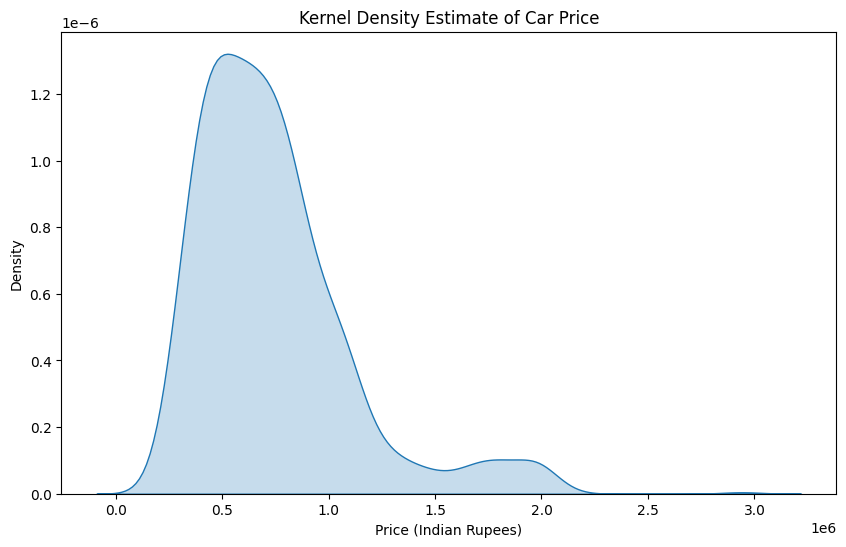

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_cars['Price'], fill=True)
plt.title('Kernel Density Estimate of Car Price')
plt.xlabel('Price (Indian Rupees)')
plt.ylabel('Density')
plt.show()

In [36]:
grouped_price_summary = df_cars.groupby('Body_Type')['Price'].describe()
display(grouped_price_summary)

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


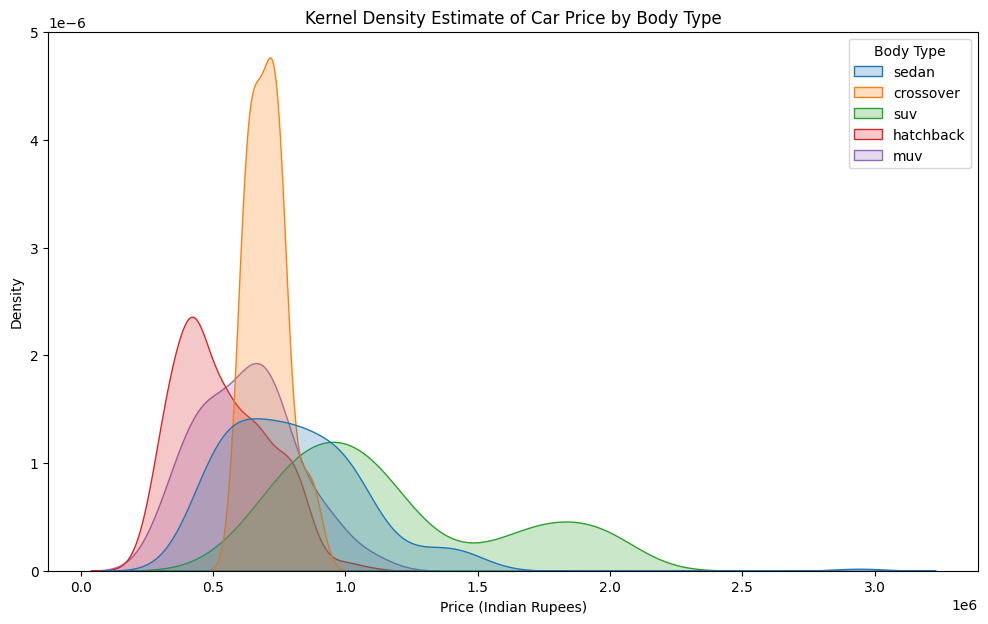

In [38]:
plt.figure(figsize=(12, 7))
ax = sns.kdeplot(data=df_cars, x='Price', hue='Body_Type', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Car Price by Body Type')
plt.xlabel('Price (Indian Rupees)')
plt.ylabel('Density')
# Set the legend title using the Axes object if a legend was created
if ax.legend_ is not None:
    ax.legend_.set_title('Body Type')
plt.show()

Based on the descriptive statistics and kernel density plot:

*   **Most Expensive Car Types (Average Price)**:
    1.  **SUV**: With an average price of approximately 1,176,495 INR, SUVs are clearly the most expensive car type.
    2.  **Sedan**: Follows with an average price of around 809,784 INR.

*   **Car Types with Most Variance (Standard Deviation)**:
    1.  **SUV**: Has the highest standard deviation of approximately 417,479 INR, indicating a wide range of prices within this category.
    2.  **Sedan**: Also shows significant variance with a standard deviation of about 286,737 INR.
    3.  **Hatchback**: While less expensive on average, it has a notable standard deviation of 173,087 INR, reflecting a considerable price spread for this body type as well.

The kernel density plot visually confirms these findings, with SUVs having a distribution shifted towards higher prices and a broader spread, especially compared to hatchbacks which are concentrated at lower prices.

In [39]:
import statsmodels.api as sm

y = df_cars['Price']
X = df_cars['Seating_Capacity']
X = sm.add_constant(X) # Add a constant (intercept) to the independent variables

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0245
Time:                        21:55:31   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

From the regression results:

*   **Slope Coefficient for `Seating_Capacity`**: `5.927e+04` (approximately 59,270)
*   **P-value**: `0.024`

**Interpretation:**

The slope coefficient for `Seating_Capacity` is approximately **59,270**. This means that for every one-unit increase in `Seating_Capacity` (i.e., one additional seat), the `Price` of the car is expected to increase by approximately **59,270 Indian Rupees**, holding all other factors constant. This relationship is statistically significant at the 5% level (p-value = 0.024).

However, it's important to note the R-squared value is very low (0.005), indicating that `Seating_Capacity` alone explains only 0.5% of the variance in car prices. This suggests that while there is a statistically significant relationship, `Seating_Capacity` is not a strong predictor of price when treated as a continuous variable.

**Reasoning**:
To treat 'Seating_Capacity' as a categorical variable, I need to create one-hot encoded (dummy) variables for each unique seating capacity, dropping the first category to avoid multicollinearity. Then, I will run a new OLS regression of 'Price' on these dummy variables.



In [41]:
df_cars['Seating_Capacity'] = df_cars['Seating_Capacity'].astype(str)
seating_capacity_dummies = pd.get_dummies(df_cars['Seating_Capacity'], prefix='Seating_Capacity', drop_first=True)

y = df_cars['Price']
X_categorical = seating_capacity_dummies.astype(int) # Convert boolean dummies to integers
X_categorical = sm.add_constant(X_categorical) # Add a constant (intercept)

model_categorical = sm.OLS(y, X_categorical)
results_categorical = model_categorical.fit()
print(results_categorical.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000267
Time:                        21:55:53   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.88e+05   3.64

From the OLS regression results with 'Seating_Capacity' treated as a categorical variable:

*   **Reference Category**: `Seating_Capacity_4` (the one dropped by `drop_first=True`) serves as the baseline.
*   **Intercept (`const`)**: The intercept of `1.88e+05` (188,000 INR) represents the average price of cars with 4 seats (our reference category).

*   **Dummy Variable Coefficients (Difference from 4-seater cars)**:
    *   `Seating_Capacity_5`: `5.465e+05` (546,500 INR). This means 5-seater cars are, on average, 546,500 INR more expensive than 4-seater cars.
    *   `Seating_Capacity_6`: `1.456e+06` (1,456,000 INR). This means 6-seater cars are, on average, 1,456,000 INR more expensive than 4-seater cars.
    *   `Seating_Capacity_7`: `7.359e+05` (735,900 INR). This means 7-seater cars are, on average, 735,900 INR more expensive than 4-seater cars.
    *   `Seating_Capacity_8`: `2.718e+05` (271,800 INR). This means 8-seater cars are, on average, 271,800 INR more expensive than 4-seater cars.

*   **Conditional Group Means (Average Price for each Seating Capacity)**:
    *   **4-seater (Reference)**: `const` = 188,000 INR
    *   **5-seater**: `const` + `Seating_Capacity_5` = 188,000 + 546,500 = 734,500 INR
    *   **6-seater**: `const` + `Seating_Capacity_6` = 188,000 + 1,456,000 = 1,644,000 INR
    *   **7-seater**: `const` + `Seating_Capacity_7` = 188,000 + 735,900 = 923,900 INR
    *   **8-seater**: `const` + `Seating_Capacity_8` = 188,000 + 271,800 = 459,800 INR

**Comparison to Continuous `Seating_Capacity` and Linearity:**

In the previous model, where `Seating_Capacity` was treated as continuous, the slope coefficient was approximately **59,270 INR**. This implied a linear increase of 59,270 INR for each additional seat.

Let's examine the *actual* price differences implied by the categorical model, starting from the 4-seater baseline:

*   **4-seater to 5-seater (1 extra seat)**: 734,500 - 188,000 = 546,500 INR (much higher than 59,270)
*   **5-seater to 6-seater (1 extra seat)**: 1,644,000 - 734,500 = 909,500 INR (even higher)
*   **6-seater to 7-seater (1 extra seat)**: 923,900 - 1,644,000 = -720,100 INR (a decrease!)
*   **7-seater to 8-seater (1 extra seat)**: 459,800 - 923,900 = -464,100 INR (a further decrease!)

**Conclusion on Linearity:**

The differences in price are **not roughly linear** in the number of seats. The categorical model reveals a complex, non-linear relationship:

*   There's a substantial price jump from 4-seaters to 5-seaters.
*   The highest average price is for 6-seater cars, suggesting they might be in a premium segment (e.g., luxury SUVs or MUVs with high-end features).
*   Prices then significantly decrease for 7-seater and 8-seater cars, which might represent more utilitarian or budget-friendly vehicle types (e.g., minivans or larger, less luxurious SUVs).

This non-linear pattern suggests that `Seating_Capacity` is not just a numerical count but also an indicator of different vehicle classes or market segments, and treating it as a categorical variable provides a much more accurate representation of its relationship with price.

In [42]:
import datetime

current_year = datetime.datetime.now().year
df_cars['Age'] = current_year - df_cars['Make_Year']

print("DataFrame head with new 'Age' column:")
display(df_cars.head())

DataFrame head with new 'Age' column:


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [43]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

y = df_cars['Price']
X_age = df_cars[['Age']]

max_degree = 5 # Test polynomial degrees from 1 to 5

mse_scores_by_degree = {}

for degree in range(1, max_degree + 1):
    # Generate polynomial features for the current degree
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_age)
    X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['Age']))

    # Prepare for 10-fold cross-validation
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    fold_mse_scores = []

    for train_index, test_index in kf.split(X_poly_df):
        X_train, X_test = X_poly_df.iloc[train_index], X_poly_df.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        fold_mse_scores.append(mean_squared_error(y_test, y_pred))

    mse_scores_by_degree[degree] = np.mean(fold_mse_scores)

# Find the optimal degree
optimal_degree = min(mse_scores_by_degree, key=mse_scores_by_degree.get)

print("Average MSE for each polynomial degree:")
for degree, mse in mse_scores_by_degree.items():
    print(f"  Degree {degree}: {mse:.2f}")

print(f"\nThe optimal number of powers (degree) to include is: {optimal_degree}")


Average MSE for each polynomial degree:
  Degree 1: 97377248064.00
  Degree 2: 97395705968.64
  Degree 3: 96743204818.44
  Degree 4: 96225038252.27
  Degree 5: 95265035513.64

The optimal number of powers (degree) to include is: 5


In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Optimal degree found in the previous step
optimal_degree = 5

y = df_cars['Price']
X_age = df_cars[['Age']]

# Generate polynomial features for the optimal degree on the entire dataset
poly_optimal = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_poly_optimal = poly_optimal.fit_transform(X_age)
X_poly_optimal_df = pd.DataFrame(X_poly_optimal, columns=poly_optimal.get_feature_names_out(['Age']))

# Train the model with the optimal polynomial features
model_optimal = LinearRegression()
model_optimal.fit(X_poly_optimal_df, y)

# Get predictions from the optimal model
y_pred_optimal = model_optimal.predict(X_poly_optimal_df)

print(f"Model trained with optimal degree {optimal_degree} polynomial features of Age. Predictions generated.")


Model trained with optimal degree 5 polynomial features of Age. Predictions generated.


**Reasoning**:
The previous steps prepared the data and trained the model. Now, to address the subtask, I need to visualize the actual prices against age and overlay the model's predicted prices against age to assess the model's fit.



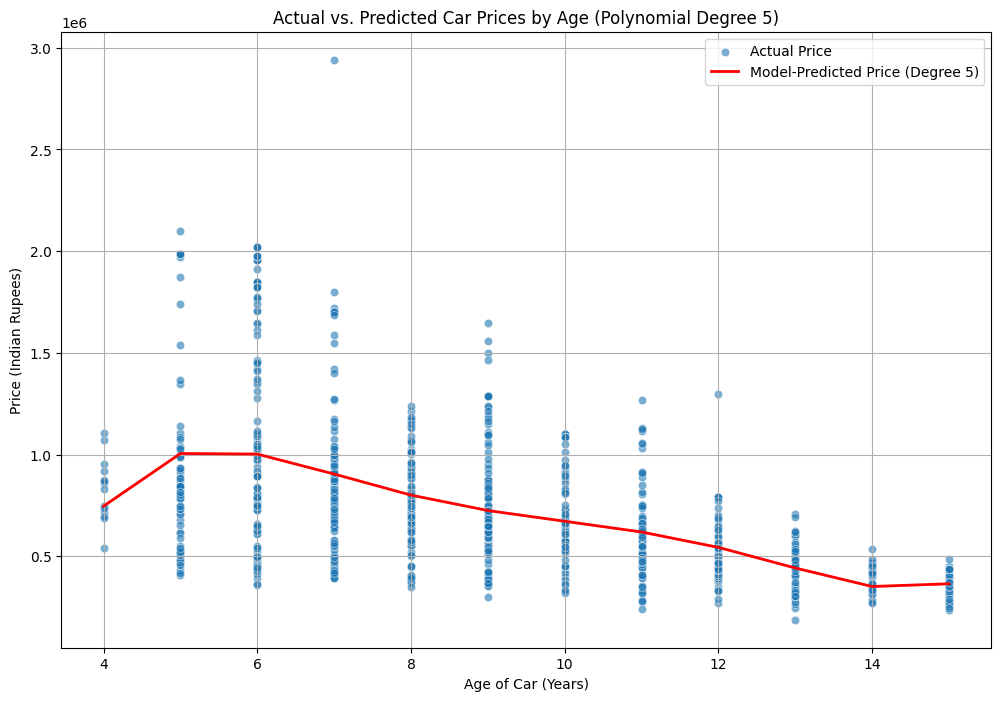

In [45]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df_cars['Age'], y=df_cars['Price'], label='Actual Price', alpha=0.6)
sns.lineplot(x=df_cars['Age'], y=y_pred_optimal, color='red', label=f'Model-Predicted Price (Degree {optimal_degree})', linewidth=2)
plt.title(f'Actual vs. Predicted Car Prices by Age (Polynomial Degree {optimal_degree})')
plt.xlabel('Age of Car (Years)')
plt.ylabel('Price (Indian Rupees)')
plt.legend()
plt.grid(True)
plt.show()


The plot visualizes the relationship between the car's `Age` and its `Price`, along with the model's predictions:

*   **Actual Price Distribution**: The scatter plot shows that actual car prices generally decrease with `Age`. There's considerable scatter, especially for newer cars, indicating other factors beyond age influence price significantly.
*   **Model-Predicted Price**: The red line represents the model's predictions using a 5th-degree polynomial of `Age`. The polynomial curve generally follows the decreasing trend of prices with age.

**Does the model accurately fit the patterns in the data?**

*   **General Trend**: The model accurately captures the overall non-linear decreasing trend of car prices as they age. The polynomial fit allows it to model the curvature, suggesting that the rate of depreciation might change over time.
*   **Limitations**: While the model captures the general trend, it does not perfectly fit all data points. There's still a large spread of actual prices around the predicted line, especially for any given age. This implies:
    *   **High Residual Variance**: The model doesn't explain a large portion of the variance in prices. Other variables (e.g., brand, model, mileage, body type, condition) are likely very influential and are not included in this simple age-based model.
    *   **Average Fit**: The model provides a good *average* fit for prices at different ages but cannot account for the individual variations of cars at the same age.
    *   **Potential for Overfitting/Underfitting**: While a 5th-degree polynomial is more flexible than a linear model, the scatter suggests that either there's significant noise not captured by age, or a different functional form might be needed, or more features are crucial. Given the cross-validation selected degree 5, it balances fitting complexity with generalization, but the overall predictive power (as implied by the scatter) is still limited.

**Conclusion**: The polynomial model of `Age` provides a reasonable approximation of the relationship between car age and price, effectively capturing the non-linear depreciation trend. However, due to the inherent variability in car prices and the absence of other critical explanatory features, it does not fully explain the price patterns. It serves as a good starting point for understanding the impact of age, but a more comprehensive model incorporating additional variables would be necessary for more accurate predictions.

*   **What are the characteristics of the 'Price' variable distribution?**
    The car 'Price' variable has a mean of approximately 741,019 INR, a standard deviation of about 367,323 INR, ranging from a minimum of 188,000 INR to a maximum of 2,941,000 INR. Its distribution is right-skewed, indicating most cars are priced lower with a tail extending towards higher prices.

*   **Which car types are the most expensive?**
    SUVs are the most expensive with an average price of approximately 1,176,495 INR, followed by Sedans at around 809,784 INR.

*   **Which car types have the most price variance?**
    SUVs exhibit the highest price variance with a standard deviation of approximately 417,479 INR. Sedans also show significant variance with a standard deviation of about 286,737 INR, and Hatchbacks have a notable standard deviation of 173,087 INR.

*   **What is the relationship between 'Price' and 'Seating_Capacity' when treated as continuous?**
    When 'Seating\_Capacity' is treated as a continuous variable, the regression analysis indicates that for every one-unit increase in seating capacity, the car's price is expected to increase by approximately 59,270 INR. This relationship is statistically significant (p-value = 0.024), but 'Seating\_Capacity' alone explains only 0.5% of the variance in car prices (R-squared = 0.005).

*   **What is the relationship between 'Price' and 'Seating_Capacity' when treated as categorical?**
    When 'Seating\_Capacity' is treated as a categorical variable (with 4-seater cars as the baseline, priced at approximately 188,000 INR):
    *   5-seater cars are, on average, 546,500 INR more expensive than 4-seater cars (average price 734,500 INR).
    *   6-seater cars are the most expensive, averaging 1,644,000 INR (1,456,000 INR more than 4-seater cars).
    *   7-seater cars average 923,900 INR (735,900 INR more than 4-seater cars).
    *   8-seater cars average 459,800 INR (271,800 INR more than 4-seater cars).
    This reveals a non-linear relationship, with 6-seater vehicles being significantly more expensive and prices decreasing for 7-seater and 8-seater vehicles relative to 6-seaters.

*   **What is the relationship between 'Price' and 'Age'?**
    The relationship between 'Price' and 'Age' is non-linear and characterized by depreciation as cars get older. A 5th-degree polynomial model was found to optimally capture this trend, indicating that the rate of depreciation changes over time. While the model captures the general decreasing trend, there is significant scatter, suggesting 'Age' alone (even with polynomial terms) does not fully explain car price variance.

*   The overall car price distribution is right-skewed, with a mean of approximately 741,019 INR and a standard deviation of 367,323 INR, highlighting a wide price range.
*   SUVs are the most expensive car type, with an average price of about 1,176,495 INR, and also exhibit the highest price variability (standard deviation of 417,479 INR).
*   Sedans follow SUVs in terms of average price (809,784 INR) and price variability (standard deviation of 286,737 INR).
*   Treating 'Seating\_Capacity' as a continuous variable shows a statistically significant but weak positive linear relationship with 'Price' (slope coefficient of approximately 59,270 INR per seat, R-squared of 0.005).
*   When 'Seating\_Capacity' is treated categorically, the relationship with 'Price' is highly non-linear, with 6-seater cars having the highest average price (1,644,000 INR), significantly higher than 4-seater cars (188,000 INR).
*   Car 'Age' has a non-linear inverse relationship with 'Price', where prices generally decrease as cars age. A 5th-degree polynomial model was identified as the optimal fit for this relationship.
